<a href="https://colab.research.google.com/github/zuhaatawakal-create/Q2.2/blob/main/Q2_2_(d%2C_e).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
=from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv('/content/heart.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Assuming 'target' is the column indicating the presence of heart disease, we will separate features (X) and the target variable (y).

In [ ]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical and numerical features
# For simplicity, assuming columns with less than 10 unique values are categorical,
# or based on common heart disease dataset column types.
categorical_features = [col for col in X.columns if X[col].dtype == 'object' or X[col].nunique() < 10]
numerical_features = [col for col in X.columns if X[col].dtype != 'object' and X[col].nunique() >= 10]

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Create a preprocessing pipeline for numerical and categorical features
# Numerical features will be scaled, categorical features will be one-hot encoded
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline that first preprocesses and then splits (or fits a model, later)
# For now, we will just transform X using the preprocessor
X_processed = preprocessor.fit_transform(X)

# Convert the processed data back to a DataFrame for easier inspection (optional, but good for understanding)
# This step can be complex due to OneHotEncoder generating new column names.
# For splitting, it's not strictly necessary to convert back to DataFrame immediately.

# Split the dataset into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Shape of X_train: (242, 30)
Shape of X_test: (61, 30)
Shape of y_train: (242,)
Shape of y_test: (61,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)


Model: Logistic Regression
Accuracy: 0.8689

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Confusion Matrix:
[[23  5]
 [ 3 30]]


### Support Vector Machine (SVM) with Linear Kernel

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model with Linear Kernel
svm_linear_model = SVC(kernel='linear', random_state=42)
svm_linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = svm_linear_model.predict(X_test)

# Evaluate the model
accuracy_linear = accuracy_score(y_test, y_pred_linear)
report_linear = classification_report(y_test, y_pred_linear)
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)

print(f"\nModel: SVM with Linear Kernel")
print(f"Accuracy: {accuracy_linear:.4f}")
print("\nClassification Report:")
print(report_linear)
print("\nConfusion Matrix:")
print(conf_matrix_linear)


Model: SVM with Linear Kernel
Accuracy: 0.8197

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61


Confusion Matrix:
[[20  8]
 [ 3 30]]


### Support Vector Machine (SVM) with RBF Kernel

In [ ]:
# Initialize and train the SVM model with RBF Kernel
svm_rbf_model = SVC(kernel='rbf', random_state=42)
svm_rbf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = svm_rbf_model.predict(X_test)

# Evaluate the model
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
report_rbf = classification_report(y_test, y_pred_rbf)
conf_matrix_rbf = confusion_matrix(y_test, y_pred_rbf)

print(f"\nModel: SVM with RBF Kernel")
print(f"Accuracy: {accuracy_rbf:.4f}")
print("\nClassification Report:")
print(report_rbf)
print("\nConfusion Matrix:")
print(conf_matrix_rbf)


Model: SVM with RBF Kernel
Accuracy: 0.8525

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82        28
           1       0.82      0.94      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.86      0.85      0.85        61


Confusion Matrix:
[[21  7]
 [ 2 31]]


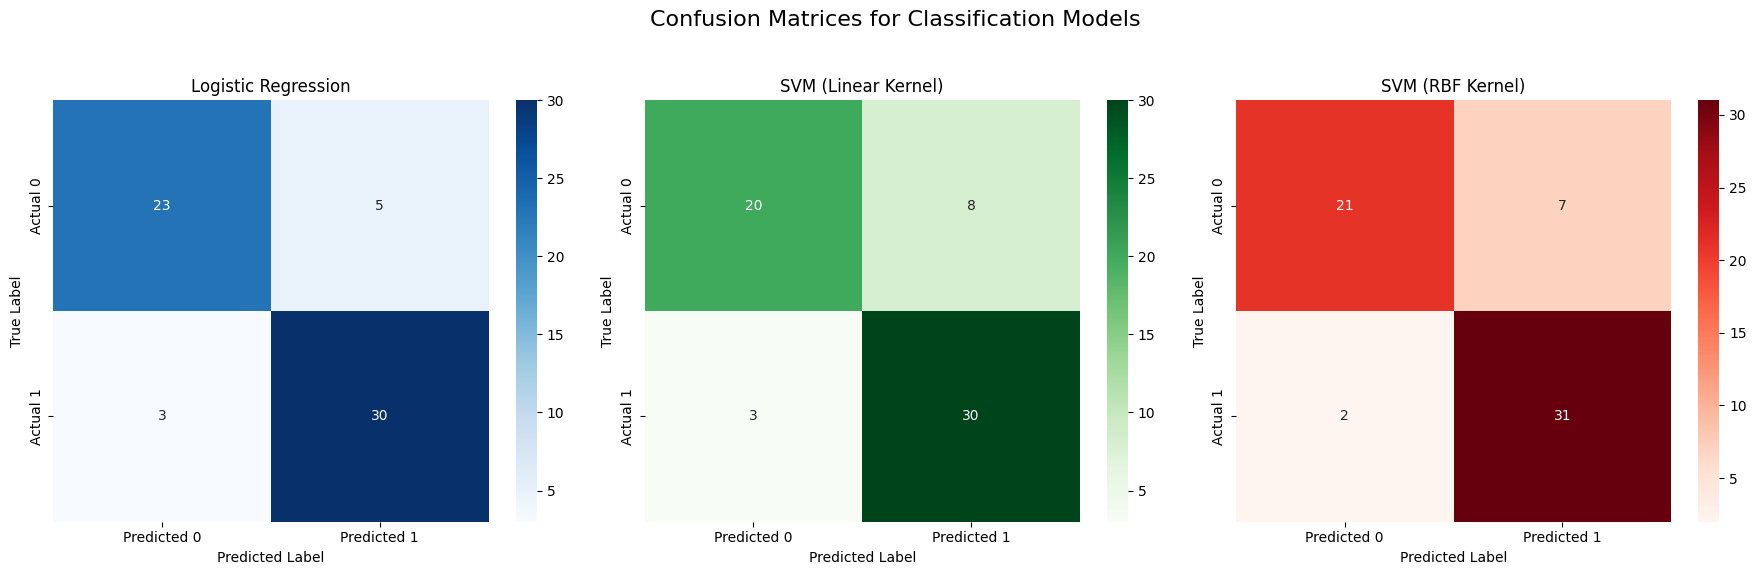

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots for the confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices for Classification Models', fontsize=16)

# Confusion Matrix for Logistic Regression
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for SVM with Linear Kernel
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('SVM (Linear Kernel)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Confusion Matrix for SVM with RBF Kernel
sns.heatmap(conf_matrix_rbf, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[2].set_title('SVM (RBF Kernel)')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

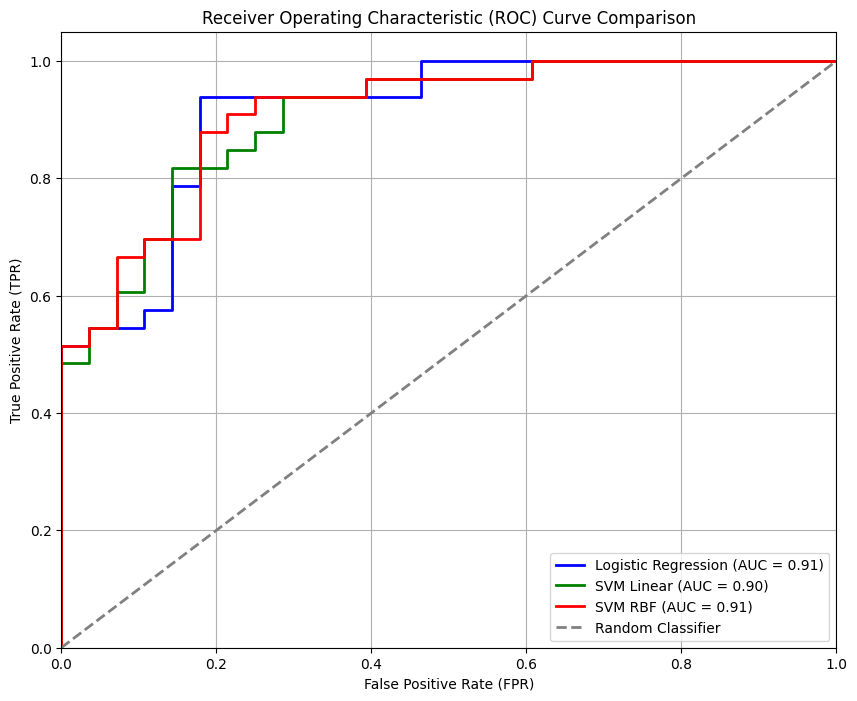

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for Logistic Regression
y_prob_lr = model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Get decision function scores for SVM (Linear Kernel)
y_score_linear = svm_linear_model.decision_function(X_test)
fpr_linear, tpr_linear, thresholds_linear = roc_curve(y_test, y_score_linear)
roc_auc_linear = auc(fpr_linear, tpr_linear)

# Get decision function scores for SVM (RBF Kernel)
y_score_rbf = svm_rbf_model.decision_function(X_test)
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test, y_score_rbf)
roc_auc_rbf = auc(fpr_rbf, tpr_rbf)

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_linear, tpr_linear, color='green', lw=2, label=f'SVM Linear (AUC = {roc_auc_linear:.2f})')
plt.plot(fpr_rbf, tpr_rbf, color='red', lw=2, label=f'SVM RBF (AUC = {roc_auc_rbf:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/tmp/ipykernel_443/1119161640.py:34: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, label='Test points')


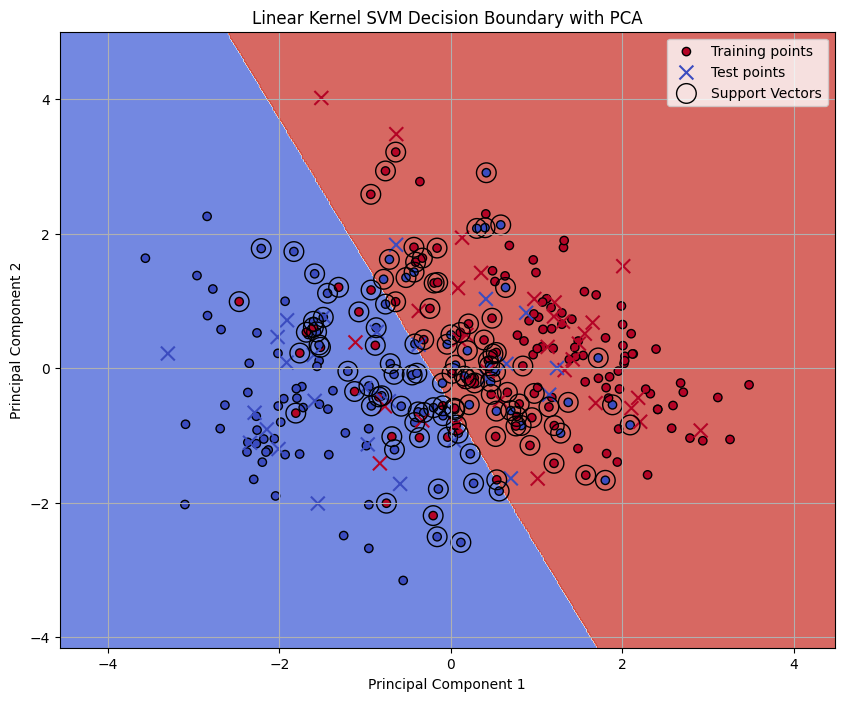

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA to reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Split the PCA-transformed data into training and testing sets
# This ensures consistency with how the original models were trained.
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Re-train a Linear Kernel SVM on the 2D PCA data for visualization purposes
svm_linear_pca = SVC(kernel='linear', random_state=42)
svm_linear_pca.fit(X_train_pca, y_train_pca)

# Create a mesh to plot the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid points
Z = svm_linear_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and training points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot training points (using X_train_pca and y_train_pca)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', label='Training points')

# Plot testing points (using X_test_pca and y_test_pca)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, label='Test points')

# Plot support vectors
plt.scatter(svm_linear_pca.support_vectors_[:, 0], svm_linear_pca.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black', marker='o', label='Support Vectors')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Linear Kernel SVM Decision Boundary with PCA')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_443/1870327217.py:36: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, label='Test points')


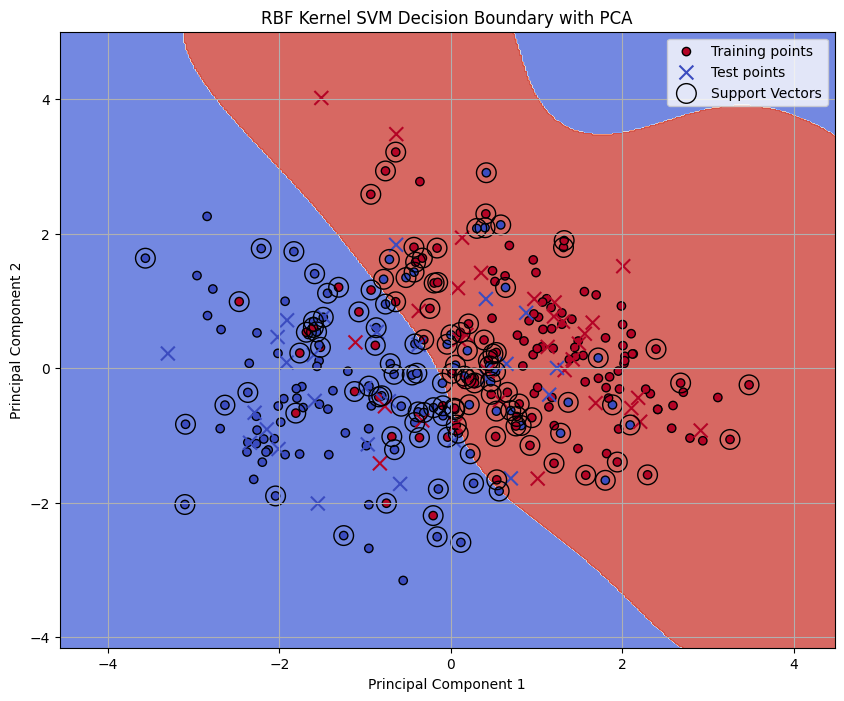

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# We already have X_pca from the previous cell, which reduced X_processed to 2 components.
# If this cell were run independently, you'd need to re-run the PCA step:
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_processed)

# Use the same split for consistency, or re-split if necessary
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Re-train an RBF Kernel SVM on the 2D PCA data for visualization purposes
svm_rbf_pca = SVC(kernel='rbf', random_state=42, gamma='scale') # gamma='scale' is default but good to be explicit
svm_rbf_pca.fit(X_train_pca, y_train_pca)

# Create a mesh to plot the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid points
Z = svm_rbf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and training points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', label='Training points')

# Plot testing points
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, label='Test points')

# Plot support vectors
plt.scatter(svm_rbf_pca.support_vectors_[:, 0], svm_rbf_pca.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black', marker='o', label='Support Vectors')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('RBF Kernel SVM Decision Boundary with PCA')
plt.legend()
plt.grid(True)
plt.show()

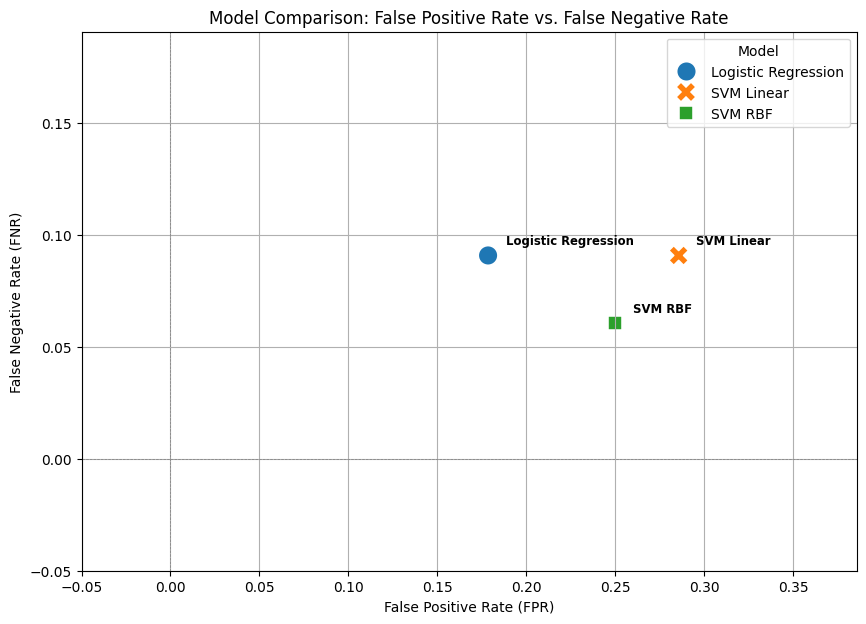

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate False Positive Rate (FPR) and False Negative Rate (FNR) for each model

# Logistic Regression
TN_lr, FP_lr, FN_lr, TP_lr = conf_matrix.ravel()
FPR_lr = FP_lr / (FP_lr + TN_lr)
FNR_lr = FN_lr / (FN_lr + TP_lr)

# SVM Linear Kernel
TN_linear, FP_linear, FN_linear, TP_linear = conf_matrix_linear.ravel()
FPR_linear = FP_linear / (FP_linear + TN_linear)
FNR_linear = FN_linear / (FN_linear + TP_linear)

# SVM RBF Kernel
TN_rbf, FP_rbf, FN_rbf, TP_rbf = conf_matrix_rbf.ravel()
FPR_rbf = FP_rbf / (FP_rbf + TN_rbf)
FNR_rbf = FN_rbf / (FN_rbf + TP_rbf)

# Create a DataFrame for easy plotting
performance_data = {
    'Model': ['Logistic Regression', 'SVM Linear', 'SVM RBF'],
    'FPR': [FPR_lr, FPR_linear, FPR_rbf],
    'FNR': [FNR_lr, FNR_linear, FNR_rbf]
}
df_performance = pd.DataFrame(performance_data)

# Plotting the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='FPR', y='FNR', hue='Model', data=df_performance, s=200, style='Model')

# Annotate each point with the model name
for i, row in df_performance.iterrows():
    plt.text(row['FPR'] + 0.01, row['FNR'] + 0.005, row['Model'], horizontalalignment='left', size='small', color='black', weight='semibold')

plt.title('Model Comparison: False Positive Rate vs. False Negative Rate')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('False Negative Rate (FNR)')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlim(-0.05, max(df_performance['FPR']) + 0.1)
plt.ylim(-0.05, max(df_performance['FNR']) + 0.1)
plt.show()

### Model Performance Comparison

| Model                  | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | AUC Score |
|------------------------|----------|---------------------|------------------|--------------------|-----------|
| Logistic Regression    | 0.8689   | 0.86                | 0.91             | 0.88               | 0.91      |
| SVM Linear Kernel      | 0.8197   | 0.79                | 0.91             | 0.85               | 0.90      |
| SVM RBF Kernel         | 0.8525   | 0.82                | 0.94             | 0.87               | 0.91      |

### Discussion: Which Classifier Performed Best?

Based on the comparison table and the previously generated plots, here's an analysis of the model performance:

*   **Logistic Regression:**
    *   Achieved the highest accuracy among the three models (0.8689).
    *   Maintained a high recall (0.91) and precision (0.86) for Class 1 (presence of heart disease), indicating a good balance between identifying positive cases and minimizing false positives.
    *   Had an AUC score of 0.91, suggesting excellent discrimination ability.
    *   In the FPR vs FNR scatter plot, it strikes a good balance, having a lower FPR than both SVM models while maintaining a comparable FNR to SVM Linear.

*   **SVM Linear Kernel:**
    *   Showed the lowest accuracy (0.8197).
    *   While recall for Class 1 was good (0.91), its precision (0.79) was the lowest, indicating a higher number of false positives compared to the other models. This is also reflected in its higher FPR on the scatter plot.
    *   The AUC score (0.90) was slightly lower than the other two.

*   **SVM RBF Kernel:**
    *   Achieved good accuracy (0.8525), slightly lower than Logistic Regression but better than SVM Linear.
    *   Stood out with the highest recall for Class 1 (0.94), meaning it was the best at identifying actual positive cases (lowest False Negatives). This is clearly visible in the FPR vs FNR scatter plot where it has the lowest FNR.
    *   Precision for Class 1 (0.82) was reasonable, but not as high as Logistic Regression.
    *   Matched Logistic Regression's AUC score of 0.91.

**Conclusion:**

If the primary goal is to **maximize the overall correct predictions (accuracy)** and maintain a good balance of precision and recall, **Logistic Regression** appears to be the best performer in this specific test set.

However, if **identifying as many true positive cases as possible (minimizing False Negatives)** is the most critical aspect (e.g., in medical diagnoses where missing a positive case is more severe than a false alarm), then the **SVM RBF Kernel** model might be preferred due to its superior recall (0.94) and lowest FNR, despite a slightly lower precision and accuracy compared to Logistic Regression.